# 04 — Evaluation: Customer Churn Model

**Objetivo:** Evaluación profunda del mejor modelo — más allá de las métricas estándar  
**Secciones críticas para producción:**
- Optimización de threshold (0.5 raramente es el óptimo)
- Calibración de probabilidades
- Interpretabilidad con SHAP
- Análisis de errores por segmento
- Impacto de negocio

---
**Índice**
1. Setup y carga
2. Métricas base en test
3. Optimización de threshold
4. Calibración de probabilidades
5. Interpretabilidad SHAP
6. Análisis de errores por segmento
7. Impacto de negocio
8. Reporte final

## 1. Setup y carga

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
import shap

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
    f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

PROCESSED_PATH = '../data/processed/'
REGISTRY_PATH  = '../models/registry/'
TRAINED_PATH   = '../models/trained/'
FIGURES_PATH   = '../artifacts/figures/'
METRICS_PATH   = '../artifacts/metrics/'
RAW_PATH       = '../data/raw/customer_churn_simulated.csv'

print('Setup completo.')

Setup completo.


/Volumes/jsf_ext/modelo_prueba/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cargar splits procesados
X_test  = np.load(f'{PROCESSED_PATH}X_test.npy')
y_test  = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()
X_oot   = np.load(f'{PROCESSED_PATH}X_oot.npy')
y_oot   = pd.read_csv(f'{PROCESSED_PATH}y_oot.csv').squeeze()
X_train = np.load(f'{PROCESSED_PATH}X_train.npy')
y_train = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()

# Índices con customer_id y period (para análisis por segmento)
test_index = pd.read_csv(f'{PROCESSED_PATH}test_index.csv', parse_dates=['period'])
oot_index  = pd.read_csv(f'{PROCESSED_PATH}oot_index.csv',  parse_dates=['period'])

with open(f'{PROCESSED_PATH}feature_names.json') as f:
    feature_names = json.load(f)

with open(f'{REGISTRY_PATH}model_metadata_v2.0.json') as f:
    metadata = json.load(f)

model = joblib.load(f'{TRAINED_PATH}{metadata["model_file"]}')

print(f'Modelo cargado : {metadata["best_model"]}')
print(f'Val  AUC-ROC   : {metadata["val_auc_roc"]}')
print(f'Test AUC-ROC   : {metadata["test_auc_roc"]}')
print(f'OOT  AUC-ROC   : {metadata["oot_auc_roc"]}')
print()

# Enriquecer índices con features clave del dataset raw para análisis de errores
df_raw = pd.read_csv(RAW_PATH, parse_dates=['period'])
test_df_raw = df_raw.merge(test_index, on=['customer_id','period'], how='inner').reset_index(drop=True)
oot_df_raw  = df_raw.merge(oot_index,  on=['customer_id','period'], how='inner').reset_index(drop=True)

print(f'Test set (raw): {test_df_raw.shape} | períodos: {test_index["period"].min().strftime("%Y-%m")} → {test_index["period"].max().strftime("%Y-%m")}')
print(f'OOT  set (raw): {oot_df_raw.shape}  | períodos: {oot_index["period"].min().strftime("%Y-%m")} → {oot_index["period"].max().strftime("%Y-%m")}')


Modelo cargado : LightGBM_Tuned
Val  AUC-ROC   : 0.8695
Test AUC-ROC   : 0.861
OOT  AUC-ROC   : 0.7622



Test set (raw): (54677, 15) | períodos: 2026-01 → 2026-06
OOT  set (raw): (45515, 15)  | períodos: 2026-07 → 2026-11


Distribución de probabilidades predichas:
count    54677.0000
mean         0.0860
std          0.1514
min          0.0000
25%          0.0113
50%          0.0477
75%          0.0957
max          1.0000
dtype: float64

Rango real de scores: [0.0000, 1.0000]


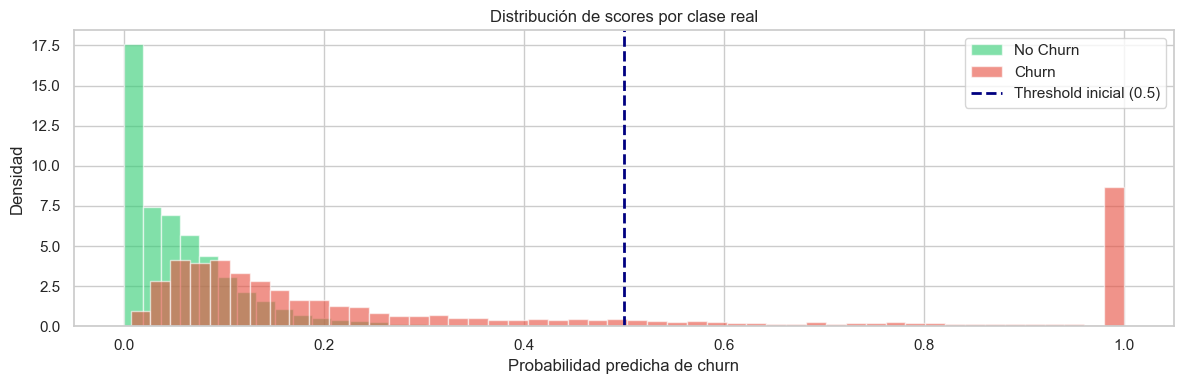

In [3]:
y_prob = model.predict_proba(X_test)[:, 1]

print('Distribución de probabilidades predichas:')
print(pd.Series(y_prob).describe().round(4))
print(f'\nRango real de scores: [{y_prob.min():.4f}, {y_prob.max():.4f}]')

# Threshold data-driven: si ningún score supera 0.5, usamos percentil 85
if (y_prob >= 0.5).sum() == 0:
    THRESHOLD_DEFAULT = round(float(np.percentile(y_prob, 85)), 3)
    print(f'\n⚠ Ninguna obs supera 0.5 — threshold ajustado a percentil 85: {THRESHOLD_DEFAULT}')
else:
    THRESHOLD_DEFAULT = 0.5

y_pred_default = (y_prob >= THRESHOLD_DEFAULT).astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(y_prob[y_test==0], bins=50, alpha=0.6, color='#2ecc71', label='No Churn', density=True)
ax.hist(y_prob[y_test==1], bins=50, alpha=0.6, color='#e74c3c', label='Churn', density=True)
ax.axvline(THRESHOLD_DEFAULT, color='navy', linestyle='--', linewidth=2,
           label=f'Threshold inicial ({THRESHOLD_DEFAULT})')
ax.set_xlabel('Probabilidad predicha de churn')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores por clase real')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Métricas base en test

In [4]:
auc_roc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)
brier   = brier_score_loss(y_test, y_prob)

print(f'AUC-ROC  : {auc_roc:.4f}')
print(f'PR-AUC   : {pr_auc:.4f}')
print(f'Brier    : {brier:.4f}  (0=perfecto, 0.25=random para 50/50)')
print()
print(classification_report(y_test, y_pred_default, target_names=['No Churn', 'Churn']))

AUC-ROC  : 0.8610
PR-AUC   : 0.5502
Brier    : 0.0563  (0=perfecto, 0.25=random para 50/50)

              precision    recall  f1-score   support

    No Churn       0.93      1.00      0.96     49804
       Churn       0.89      0.27      0.42      4873

    accuracy                           0.93     54677
   macro avg       0.91      0.63      0.69     54677
weighted avg       0.93      0.93      0.92     54677



## 3. Optimización de threshold

> 0.5 es arbitrario. En churn, el costo de un **falso negativo** (cliente que churna y no detectamos)
> suele ser mayor que el de un **falso positivo** (acción de retención innecesaria).

In [5]:
# Rango de thresholds dentro del rango real de scores
score_min  = float(np.percentile(y_prob, 5))
score_max  = float(np.percentile(y_prob, 99))
thresholds = np.round(np.arange(score_min, score_max, 0.005), 3)

threshold_metrics = []
for t in thresholds:
    y_pred_t  = (y_prob >= t).astype(int)
    tp = ((y_pred_t==1) & (y_test==1)).sum()
    fp = ((y_pred_t==1) & (y_test==0)).sum()
    fn = ((y_pred_t==0) & (y_test==1)).sum()
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    threshold_metrics.append({
        'threshold'  : round(float(t), 3),
        'precision'  : round(precision, 4),
        'recall'     : round(recall, 4),
        'f1'         : round(f1, 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn),
        'flagged_pct': round((tp+fp)/len(y_test)*100, 2)
    })

thresh_df    = pd.DataFrame(threshold_metrics)
best_f1_row  = thresh_df.loc[thresh_df['f1'].idxmax()]
recall_70    = thresh_df[thresh_df['recall'] >= 0.70]
best_biz_row = recall_70.sort_values('precision', ascending=False).iloc[0] if len(recall_70)>0 \
               else thresh_df.loc[thresh_df['recall'].idxmax()]

closest = thresh_df.iloc[(thresh_df['threshold']-THRESHOLD_DEFAULT).abs().argsort().iloc[0]]
print(f'Score range         [{y_prob.min():.4f}, {y_prob.max():.4f}]')
print(f'Threshold inicial   {THRESHOLD_DEFAULT:.3f}  → P: {closest["precision"]:.4f} | R: {closest["recall"]:.4f} | F1: {closest["f1"]:.4f}')
print(f'Threshold óptimo F1 {best_f1_row["threshold"]:.3f}  → P: {best_f1_row["precision"]:.4f} | R: {best_f1_row["recall"]:.4f} | F1: {best_f1_row["f1"]:.4f}')
print(f'Threshold negocio   {best_biz_row["threshold"]:.3f}  → P: {best_biz_row["precision"]:.4f} | R: {best_biz_row["recall"]:.4f} | F1: {best_biz_row["f1"]:.4f}')


Score range         [0.0000, 1.0000]
Threshold inicial   0.500  → P: 0.8880 | R: 0.2717 | F1: 0.4161
Threshold óptimo F1 0.225  → P: 0.5848 | R: 0.4258 | F1: 0.4928
Threshold negocio   0.100  → P: 0.2688 | R: 0.7080 | F1: 0.3896


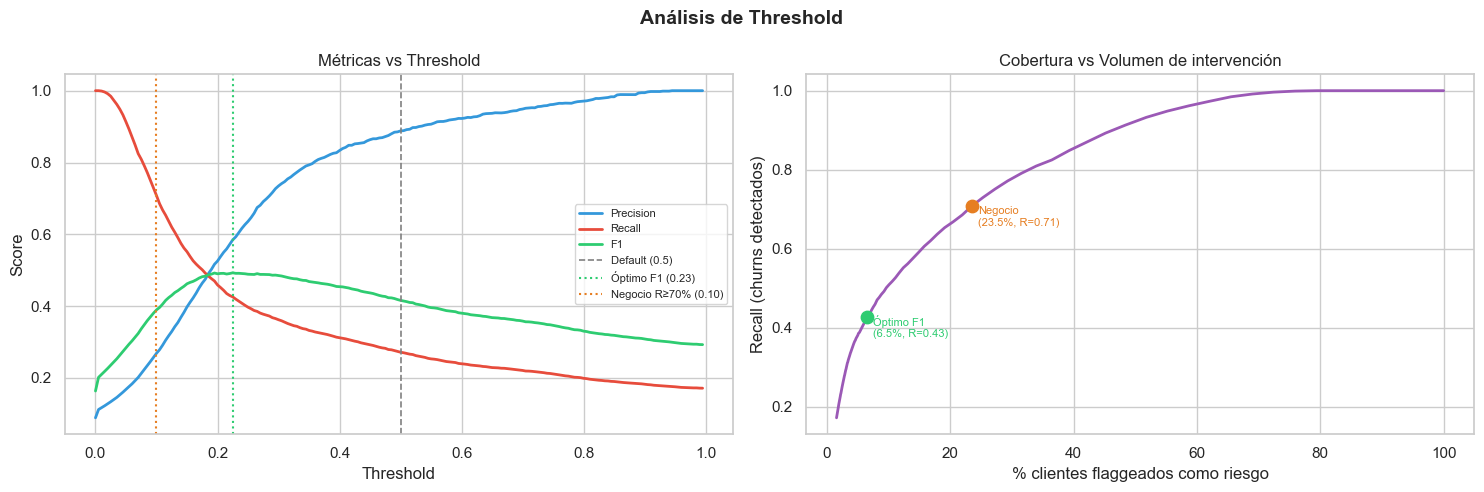

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Precision / Recall / F1 vs Threshold
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#3498db', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#e74c3c', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='#2ecc71', linewidth=2)
axes[0].axvline(THRESHOLD_DEFAULT,          color='gray',  linestyle='--', linewidth=1.2, label=f'Default ({THRESHOLD_DEFAULT})')
axes[0].axvline(best_f1_row['threshold'],   color='#2ecc71', linestyle=':',  linewidth=1.5, label=f'Óptimo F1 ({best_f1_row["threshold"]:.2f})')
axes[0].axvline(best_biz_row['threshold'],  color='#e67e22', linestyle=':',  linewidth=1.5, label=f'Negocio R≥70% ({best_biz_row["threshold"]:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas vs Threshold')
axes[0].legend(fontsize=8)

# % clientes flaggeados vs recall
axes[1].plot(thresh_df['flagged_pct'], thresh_df['recall'], color='#9b59b6', linewidth=2)
axes[1].set_xlabel('% clientes flaggeados como riesgo')
axes[1].set_ylabel('Recall (churns detectados)')
axes[1].set_title('Cobertura vs Volumen de intervención')
# Marcar puntos clave
for row, label, color in [
    (best_f1_row, 'Óptimo F1', '#2ecc71'),
    (best_biz_row, 'Negocio', '#e67e22')
]:
    axes[1].scatter(row['flagged_pct'], row['recall'], color=color, s=80, zorder=5)
    axes[1].annotate(f"{label}\n({row['flagged_pct']:.1f}%, R={row['recall']:.2f})",
                     xy=(row['flagged_pct'], row['recall']),
                     xytext=(row['flagged_pct']+1, row['recall']-0.05),
                     fontsize=8, color=color)

plt.suptitle('Análisis de Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Calibración de probabilidades

> Un modelo bien calibrado significa que cuando predice 80% de churn, el 80% real sí churna.
> Crítico si los scores se usan para priorización o cálculo de valor esperado.

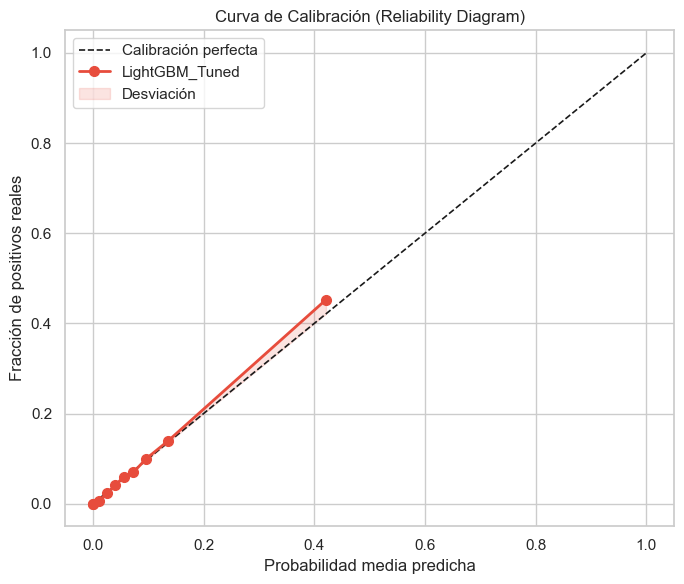

Brier Score: 0.0563
  < 0.05 → excelente | 0.05-0.10 → bueno | > 0.10 → revisar calibración

Si el modelo sobreestima (curva por encima de la diagonal):
  → Aplicar CalibratedClassifierCV con method="isotonic" en producción


In [7]:
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Calibración perfecta')
ax.plot(mean_pred, fraction_pos, 'o-', color='#e74c3c', linewidth=2,
        markersize=7, label=f'{metadata["best_model"]}')
ax.fill_between(mean_pred, fraction_pos, mean_pred,
                alpha=0.15, color='#e74c3c', label='Desviación')
ax.set_xlabel('Probabilidad media predicha')
ax.set_ylabel('Fracción de positivos reales')
ax.set_title('Curva de Calibración (Reliability Diagram)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Brier Score: {brier_score_loss(y_test, y_prob):.4f}')
print('  < 0.05 → excelente | 0.05-0.10 → bueno | > 0.10 → revisar calibración')
print()
print('Si el modelo sobreestima (curva por encima de la diagonal):')
print('  → Aplicar CalibratedClassifierCV con method="isotonic" en producción')

## 5. Interpretabilidad — SHAP

> SHAP (SHapley Additive exPlanations): cuánto aporta cada feature a la predicción de cada observación.  
> Fundamental para explicar decisiones del modelo a stakeholders no técnicos.

In [8]:
# SHAP TreeExplainer — optimizado para modelos de árbol (LightGBM, XGBoost, CatBoost)
# Usamos una muestra del test para velocidad
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(1000, len(X_test)), replace=False)
X_shap = X_test[sample_idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Para clasificación binaria algunos modelos retornan lista [clase0, clase1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP calculado sobre {len(X_shap)} observaciones.')
print(f'Shape SHAP values: {shap_values.shape}')

SHAP calculado sobre 1000 observaciones.
Shape SHAP values: (1000, 79)


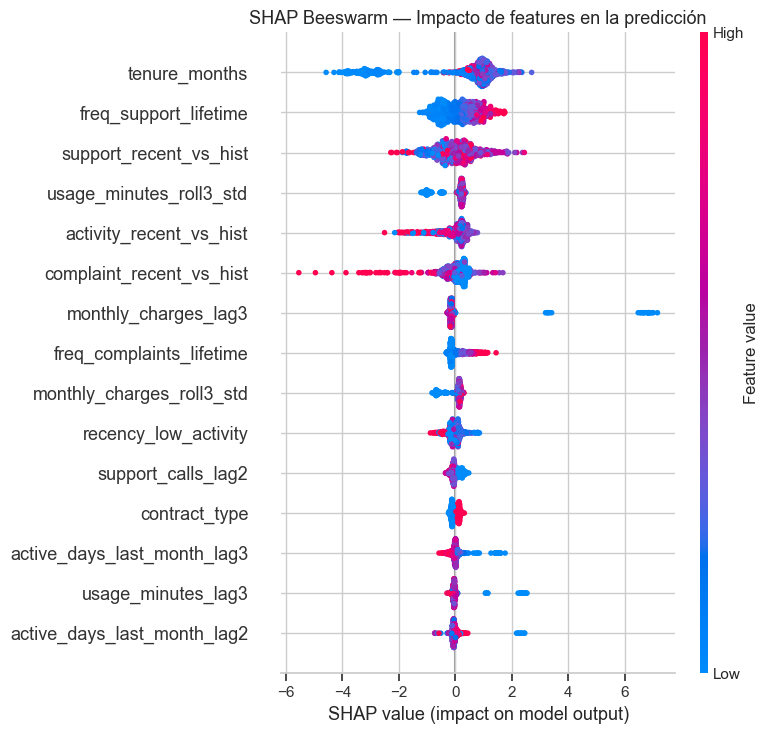

In [9]:
# Beeswarm: impacto global de cada feature
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    plot_type='dot',
    show=False,
    max_display=15
)
plt.title('SHAP Beeswarm — Impacto de features en la predicción', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

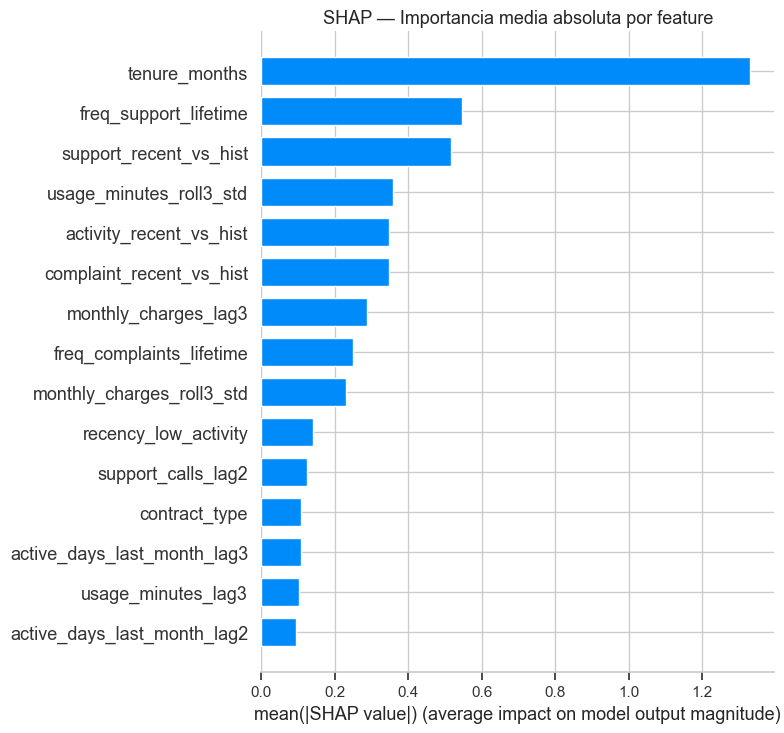

In [10]:
# Bar plot: importancia media absoluta
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('SHAP — Importancia media absoluta por feature', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Observación analizada:
  Score predicho : 0.9999
  Churn real     : 1


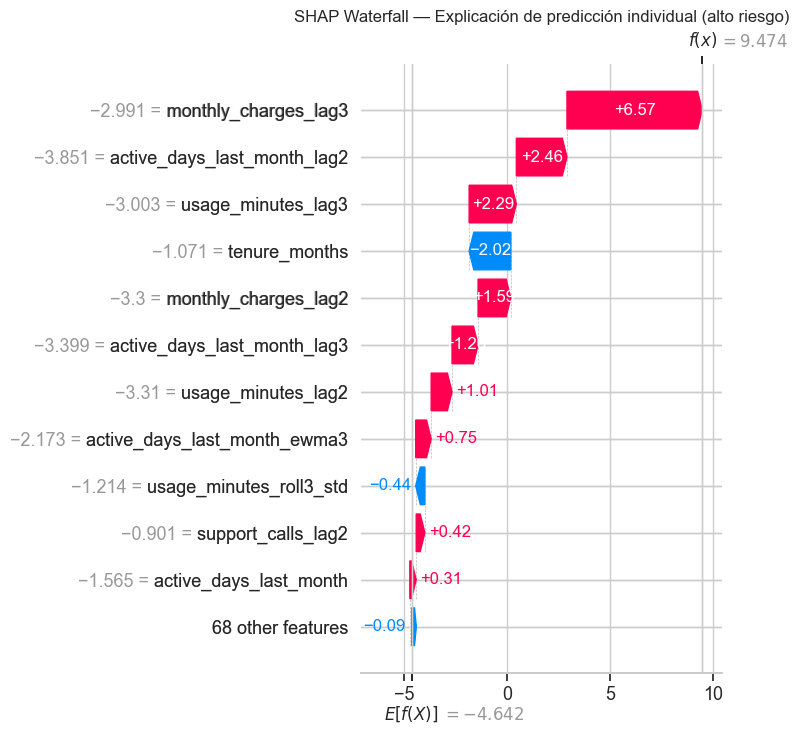

In [11]:
high_risk_idx = np.argsort(y_prob[sample_idx])[-1]

print(f'Observación analizada:')
print(f'  Score predicho : {y_prob[sample_idx[high_risk_idx]]:.4f}')
print(f'  Churn real     : {y_test.iloc[sample_idx[high_risk_idx]]}')

base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) \
           else float(explainer.expected_value)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=base_val,
        data=X_shap[high_risk_idx],
        feature_names=feature_names
    ),
    show=False, max_display=12
)
plt.title('SHAP Waterfall — Explicación de predicción individual (alto riesgo)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Análisis de errores por segmento

> El modelo puede funcionar bien en promedio pero mal en segmentos específicos.  
> Esto es crítico para fairness y para identificar dónde necesita más datos o reentrenamiento.

In [12]:
assert len(test_df_raw) == len(y_prob), f'Tamaños no coinciden: test_df_raw={len(test_df_raw)}, y_prob={len(y_prob)}'

ANALYSIS_THRESHOLD = float(best_f1_row['threshold'])
y_pred_analysis    = (y_prob >= ANALYSIS_THRESHOLD).astype(int)

analysis_df = test_df_raw[['customer_id','period','region','contract_type','payment_method',
                            'tenure_months','monthly_charges']].copy()
analysis_df['y_true'] = y_test.values
analysis_df['y_prob'] = y_prob
analysis_df['y_pred'] = y_pred_analysis
analysis_df['error_type'] = 'TN'
analysis_df.loc[(analysis_df['y_true']==1) & (analysis_df['y_pred']==1), 'error_type'] = 'TP'
analysis_df.loc[(analysis_df['y_true']==0) & (analysis_df['y_pred']==1), 'error_type'] = 'FP'
analysis_df.loc[(analysis_df['y_true']==1) & (analysis_df['y_pred']==0), 'error_type'] = 'FN'

print(f'Threshold usado: {ANALYSIS_THRESHOLD}')
print('\nDistribución de tipos de predicción:')
print(analysis_df['error_type'].value_counts())


Threshold usado: 0.225

Distribución de tipos de predicción:
error_type
TN    48331
FN     2798
TP     2075
FP     1473
Name: count, dtype: int64


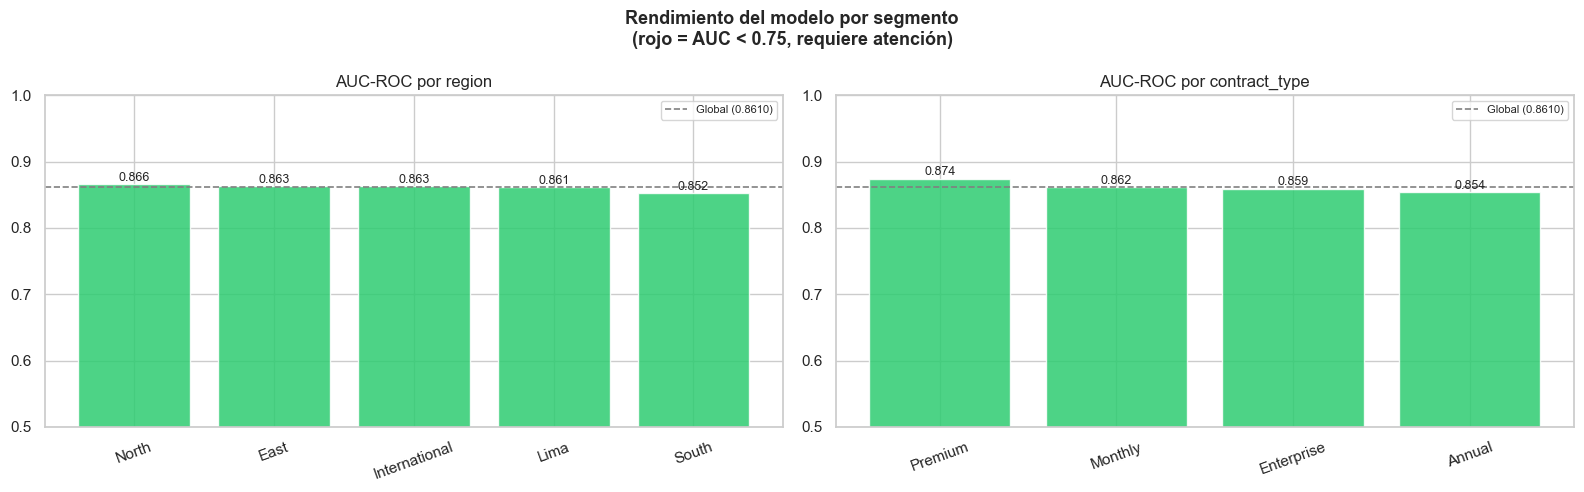

In [13]:
# AUC-ROC por segmento
def auc_by_segment(df, segment_col):
    rows = []
    for seg, grp in df.groupby(segment_col):
        if grp['y_true'].nunique() < 2:
            continue
        auc = roc_auc_score(grp['y_true'], grp['y_prob'])
        rows.append({'segment': seg, 'auc_roc': round(auc, 4), 'n': len(grp),
                     'churn_rate': round(grp['y_true'].mean() * 100, 2)})
    return pd.DataFrame(rows).sort_values('auc_roc', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(['region', 'contract_type']):
    seg_df = auc_by_segment(analysis_df, col)
    colors = ['#e74c3c' if v < 0.75 else '#2ecc71' for v in seg_df['auc_roc']]
    bars = axes[i].bar(seg_df['segment'], seg_df['auc_roc'], color=colors,
                       alpha=0.85, edgecolor='white')
    axes[i].axhline(auc_roc, color='gray', linestyle='--', linewidth=1.2,
                    label=f'Global ({auc_roc:.4f})')
    axes[i].set_title(f'AUC-ROC por {col}')
    axes[i].set_ylim(0.5, 1.0)
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, seg_df['auc_roc']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Rendimiento del modelo por segmento\n(rojo = AUC < 0.75, requiere atención)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}auc_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
fn_df = analysis_df[analysis_df['error_type'] == 'FN']
tp_df = analysis_df[analysis_df['error_type'] == 'TP']

print(f'Falsos negativos (churns no detectados): {len(fn_df)}')
print(f'Verdaderos positivos (churns detectados): {len(tp_df)}')
print()

num_compare = ['tenure_months', 'monthly_charges']
if len(tp_df) > 0 and len(fn_df) > 0:
    compare = pd.DataFrame({
        'FN (no detectados)': fn_df[num_compare].mean().round(2),
        'TP (detectados)'   : tp_df[num_compare].mean().round(2)
    })
    compare['Diferencia'] = (compare['FN (no detectados)'] - compare['TP (detectados)']).round(2)
    print('Comparación FN vs TP:')
    print(compare)
else:
    print('⚠ No hay suficientes TPs para comparar — considerar bajar el threshold.')

print('\nDistribución de FN por contract_type:')
print(fn_df['contract_type'].value_counts(normalize=True).round(3))


Falsos negativos (churns no detectados): 2798
Verdaderos positivos (churns detectados): 2075

Comparación FN vs TP:
                 FN (no detectados)  TP (detectados)  Diferencia
tenure_months                 11.59            10.20        1.39
monthly_charges               70.85            70.93       -0.08

Distribución de FN por contract_type:
contract_type
Annual        0.356
Monthly       0.309
Premium       0.170
Enterprise    0.164
Name: proportion, dtype: float64


## 7. Impacto de negocio

> Traducir las métricas del modelo a valor monetario.  
> Supuestos conservadores — deben ser validados con el equipo de negocio.

In [15]:
# Supuestos de negocio (ajustar con datos reales)
AVG_MONTHLY_REVENUE    = 60.0   # USD — promedio de monthly_charges del dataset
AVG_TENURE_SAVED       = 6      # meses que se retiene a un cliente con intervención exitosa
INTERVENTION_SUCCESS   = 0.30   # 30% de los clientes contactados se retienen
COST_PER_INTERVENTION  = 15.0   # USD — costo de acción de retención (descuento, llamada, etc.)

REVENUE_PER_SAVED_CUSTOMER = AVG_MONTHLY_REVENUE * AVG_TENURE_SAVED
NET_VALUE_PER_TP = (REVENUE_PER_SAVED_CUSTOMER * INTERVENTION_SUCCESS) - COST_PER_INTERVENTION
NET_VALUE_PER_FP = -COST_PER_INTERVENTION

print(f'Supuestos:')
print(f'  Ingreso mensual promedio     : ${AVG_MONTHLY_REVENUE}')
print(f'  Meses retenidos por acción   : {AVG_TENURE_SAVED}')
print(f'  Tasa de éxito de intervención: {INTERVENTION_SUCCESS*100:.0f}%')
print(f'  Costo por intervención       : ${COST_PER_INTERVENTION}')
print()
print(f'Valor neto por TP (churn detectado): ${NET_VALUE_PER_TP:.2f}')
print(f'Costo por FP (falsa alarma)        : ${NET_VALUE_PER_FP:.2f}')

Supuestos:
  Ingreso mensual promedio     : $60.0
  Meses retenidos por acción   : 6
  Tasa de éxito de intervención: 30%
  Costo por intervención       : $15.0

Valor neto por TP (churn detectado): $93.00
Costo por FP (falsa alarma)        : $-15.00


Threshold óptimo por valor de negocio: 0.130
  Valor neto estimado : $189,666
  TP                  : 2952.0
  FP                  : 5658.0
  Intervenciones      : 8610.0


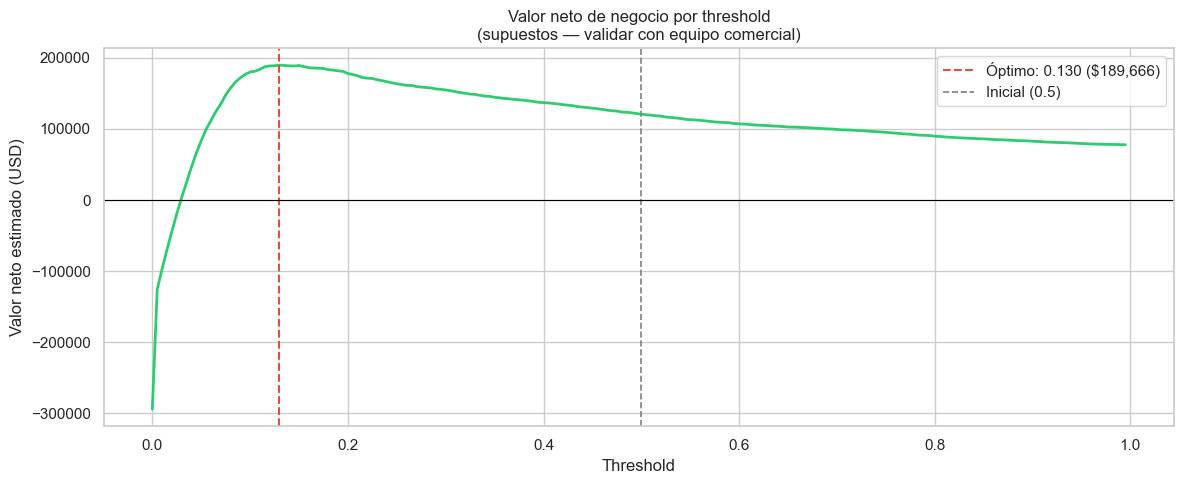

In [16]:
business_metrics = []
for t in thresholds:
    y_pred_t  = (y_prob >= t).astype(int)
    tp = int(((y_pred_t==1) & (y_test==1)).sum())
    fp = int(((y_pred_t==1) & (y_test==0)).sum())
    net_value = tp * NET_VALUE_PER_TP + fp * NET_VALUE_PER_FP
    business_metrics.append({
        'threshold': round(float(t), 3),
        'net_value': round(net_value, 2),
        'tp': tp, 'fp': fp, 'interventions': tp + fp
    })

biz_df = pd.DataFrame(business_metrics)
best_biz_threshold = biz_df.loc[biz_df['net_value'].idxmax()]

print(f'Threshold óptimo por valor de negocio: {best_biz_threshold["threshold"]:.3f}')
print(f'  Valor neto estimado : ${best_biz_threshold["net_value"]:,.0f}')
print(f'  TP                  : {best_biz_threshold["tp"]}')
print(f'  FP                  : {best_biz_threshold["fp"]}')
print(f'  Intervenciones      : {best_biz_threshold["interventions"]}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(biz_df['threshold'], biz_df['net_value'], color='#2ecc71', linewidth=2)
ax.axvline(best_biz_threshold['threshold'], color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Óptimo: {best_biz_threshold["threshold"]:.3f} (${best_biz_threshold["net_value"]:,.0f})')
ax.axvline(THRESHOLD_DEFAULT, color='gray', linestyle='--', linewidth=1.2,
           label=f'Inicial ({THRESHOLD_DEFAULT})')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Threshold')
ax.set_ylabel('Valor neto estimado (USD)')
ax.set_title('Valor neto de negocio por threshold\n(supuestos — validar con equipo comercial)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}business_value_threshold.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Reporte final

In [17]:
FINAL_THRESHOLD = float(best_biz_threshold['threshold'])
y_pred_final    = (y_prob >= FINAL_THRESHOLD).astype(int)

print('=' * 60)
print('REPORTE FINAL — CHURN MODEL v1.0')
print('=' * 60)
print(f"""
MODELO
  Algoritmo      : {metadata['best_model']}
  Versión        : {metadata['version']}
  Features       : {metadata['n_features']}
  Balanceo       : {metadata['balancing']}
  Entrenado en   : {metadata.get('timestamp', 'N/A')}

MÉTRICAS EN TEST
  AUC-ROC        : {auc_roc:.4f}
  PR-AUC         : {pr_auc:.4f}
  Brier Score    : {brier_score_loss(y_test, y_prob):.4f}

THRESHOLD
  Score range    : [{y_prob.min():.4f}, {y_prob.max():.4f}]
  Óptimo F1      : {best_f1_row['threshold']:.3f}  → F1: {best_f1_row['f1']:.4f}
  Negocio        : {FINAL_THRESHOLD:.3f}  → Valor neto: ${best_biz_threshold['net_value']:,.0f}
  ✓ Recomendado  : {FINAL_THRESHOLD:.3f}

PUNTOS DE ATENCIÓN PARA PRODUCCIÓN
  1. Buckets por quintiles calculados sobre train (no recalcular en prod)
  2. Monitorear AUC por segmento mensualmente
  3. Reentrenar cuando churn rate real se desvíe > 2pp del train
  4. Validar supuestos de negocio con equipo comercial
""")
print('=' * 60)

metadata['final_threshold']         = FINAL_THRESHOLD
metadata['final_f1']                = float(round(f1_score(y_test, y_pred_final), 4))
metadata['final_auc_roc']           = float(round(auc_roc, 4))
metadata['biz_threshold']           = float(best_biz_threshold['threshold'])
metadata['biz_net_value_estimated'] = float(best_biz_threshold['net_value'])

with open(f'{REGISTRY_PATH}model_metadata_v1.0.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('\nMetadata actualizada con threshold final.')


REPORTE FINAL — CHURN MODEL v1.0

MODELO
  Algoritmo      : LightGBM_Tuned
  Versión        : v2.0
  Features       : 79
  Balanceo       : none
  Entrenado en   : 20260412_0239

MÉTRICAS EN TEST
  AUC-ROC        : 0.8610
  PR-AUC         : 0.5502
  Brier Score    : 0.0563

THRESHOLD
  Score range    : [0.0000, 1.0000]
  Óptimo F1      : 0.225  → F1: 0.4928
  Negocio        : 0.130  → Valor neto: $189,666
  ✓ Recomendado  : 0.130

PUNTOS DE ATENCIÓN PARA PRODUCCIÓN
  1. Buckets por quintiles calculados sobre train (no recalcular en prod)
  2. Monitorear AUC por segmento mensualmente
  3. Reentrenar cuando churn rate real se desvíe > 2pp del train
  4. Validar supuestos de negocio con equipo comercial


Metadata actualizada con threshold final.


## 8. Quintile Bucketing — Segmentación de Riesgo

Se ajustan los cortes de quintil **solo sobre train** (mismo principio que StandardScaler — evita data leakage). Luego se aplican a val y test. Resultado: 5 segmentos de riesgo ordenados de mayor a menor probabilidad de churn.

In [18]:
import joblib

# ──────────────────────────────────────────────────────────────────
# 1. Obtener scores sobre train (para ajustar los cortes)
# ──────────────────────────────────────────────────────────────────
X_train = np.load(f'{PROCESSED_PATH}X_train.npy')
y_train = pd.read_csv(f'{PROCESSED_PATH}y_train.csv').squeeze()

y_prob_train = model.predict_proba(X_train)[:, 1]

# ──────────────────────────────────────────────────────────────────
# 2. Calcular cortes de quintil sobre TRAIN (fit)
# ──────────────────────────────────────────────────────────────────
quintile_cuts = np.percentile(y_prob_train, [20, 40, 60, 80])

LABELS      = ['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto']
LABEL_ORDER = LABELS  # de menor a mayor riesgo

print('Cortes de quintil (ajustados en train):')
print(f'  Q20 : {quintile_cuts[0]:.4f}')
print(f'  Q40 : {quintile_cuts[1]:.4f}')
print(f'  Q60 : {quintile_cuts[2]:.4f}')
print(f'  Q80 : {quintile_cuts[3]:.4f}')
print()
print('Interpretación:')
print(f'  Muy bajo : score < {quintile_cuts[0]:.4f}')
print(f'  Bajo     : {quintile_cuts[0]:.4f} ≤ score < {quintile_cuts[1]:.4f}')
print(f'  Medio    : {quintile_cuts[1]:.4f} ≤ score < {quintile_cuts[2]:.4f}')
print(f'  Alto     : {quintile_cuts[2]:.4f} ≤ score < {quintile_cuts[3]:.4f}')
print(f'  Muy alto : score ≥ {quintile_cuts[3]:.4f}')

# ──────────────────────────────────────────────────────────────────
# 3. Función de bucketing reutilizable
# ──────────────────────────────────────────────────────────────────
def assign_quintile(scores, cuts):
    """Asigna label de riesgo según cortes ajustados en train."""
    labels = np.select(
        [scores < cuts[0],
         scores < cuts[1],
         scores < cuts[2],
         scores < cuts[3]],
        ['Muy bajo', 'Bajo', 'Medio', 'Alto'],
        default='Muy alto'
    )
    return labels

# ──────────────────────────────────────────────────────────────────
# 4. Aplicar a train, val y test
# ──────────────────────────────────────────────────────────────────
X_val  = np.load(f'{PROCESSED_PATH}X_val.npy')
y_val  = pd.read_csv(f'{PROCESSED_PATH}y_val.csv').squeeze()

y_prob_val  = model.predict_proba(X_val)[:, 1]
# y_prob (test) ya está calculado arriba

bucket_train = assign_quintile(y_prob_train, quintile_cuts)
bucket_val   = assign_quintile(y_prob_val,   quintile_cuts)
bucket_test  = assign_quintile(y_prob,       quintile_cuts)

# ──────────────────────────────────────────────────────────────────
# 5. Validación: churn rate por segmento en test
# ──────────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'y_true'  : y_test.values,
    'y_prob'  : y_prob,
    'segmento': bucket_test
})

summary = (results_df.groupby('segmento')
           .agg(
               n         = ('y_true', 'count'),
               n_churn   = ('y_true', 'sum'),
               churn_rate= ('y_true', 'mean'),
               score_mean= ('y_prob', 'mean'),
               score_min = ('y_prob', 'min'),
               score_max = ('y_prob', 'max'),
           )
           .reindex(LABELS)
           .reset_index())

print()
print('Churn rate por segmento (TEST):')
print(summary.to_string(index=False, float_format='{:.4f}'.format))


Cortes de quintil (ajustados en train):
  Q20 : 0.0002
  Q40 : 0.0173
  Q60 : 0.0440
  Q80 : 0.0882

Interpretación:
  Muy bajo : score < 0.0002
  Bajo     : 0.0002 ≤ score < 0.0173
  Medio    : 0.0173 ≤ score < 0.0440
  Alto     : 0.0440 ≤ score < 0.0882
  Muy alto : score ≥ 0.0882



Churn rate por segmento (TEST):
segmento     n  n_churn  churn_rate  score_mean  score_min  score_max
Muy bajo  8395        0      0.0000      0.0000     0.0000     0.0002
    Bajo  7517       24      0.0032      0.0076     0.0002     0.0173
   Medio 10087      292      0.0289      0.0306     0.0173     0.0440
    Alto 13383      866      0.0647      0.0642     0.0440     0.0882
Muy alto 15295     3691      0.2413      0.2274     0.0882     1.0000


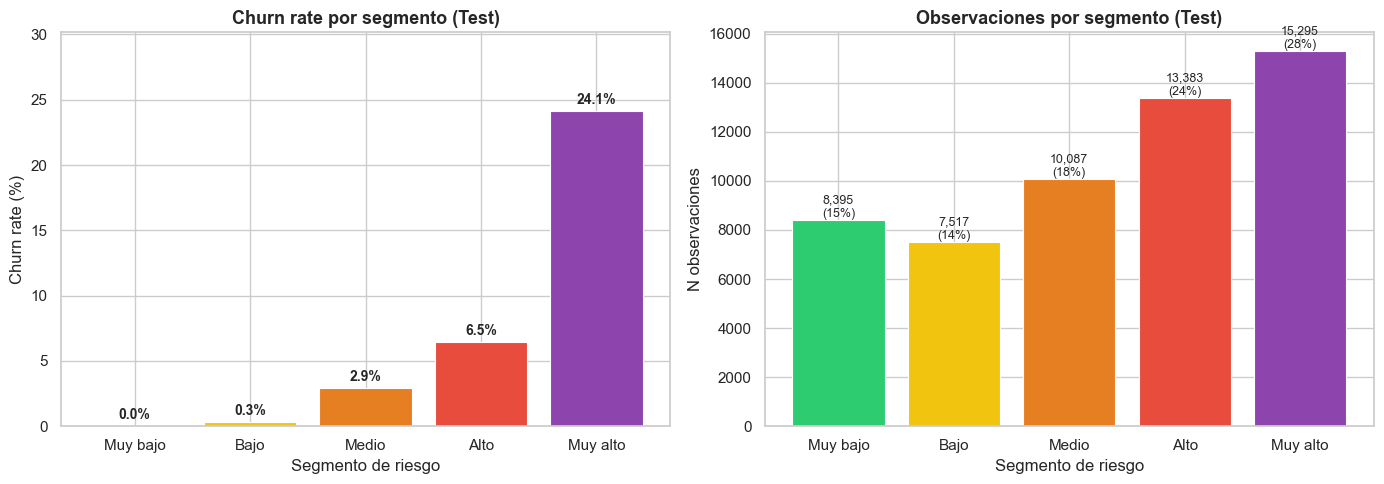


Lift por segmento:
  Muy bajo  : churn rate 0.0%  |  lift 0.00x
  Bajo      : churn rate 0.3%  |  lift 0.04x
  Medio     : churn rate 2.9%  |  lift 0.32x
  Alto      : churn rate 6.5%  |  lift 0.73x
  Muy alto  : churn rate 24.1%  |  lift 2.71x


In [19]:
# ──────────────────────────────────────────────────────────────────
# 6. Visualización
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Churn rate por segmento
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
bars = axes[0].bar(summary['segmento'], summary['churn_rate'] * 100,
                   color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Churn rate por segmento (Test)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_xlabel('Segmento de riesgo')
for bar, val in zip(bars, summary['churn_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, summary['churn_rate'].max() * 100 * 1.25)

# b) Distribución de observaciones por segmento
axes[1].bar(summary['segmento'], summary['n'], color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Observaciones por segmento (Test)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('N observaciones')
axes[1].set_xlabel('Segmento de riesgo')
for i, (bar, row) in enumerate(zip(axes[1].patches, summary.itertuples())):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{row.n:,}\n({row.n/len(results_df)*100:.0f}%)',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}quintile_bucketing.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Lift por segmento:')
base_rate = y_test.mean()
for _, row in summary.iterrows():
    lift = row['churn_rate'] / base_rate if base_rate > 0 else 0
    print(f'  {row["segmento"]:10s}: churn rate {row["churn_rate"]*100:.1f}%  |  lift {lift:.2f}x')


In [20]:
# ──────────────────────────────────────────────────────────────────
# 7. Guardar artefactos de bucketing
# ──────────────────────────────────────────────────────────────────
bucketing_artifact = {
    'quintile_cuts': quintile_cuts.tolist(),
    'labels': LABELS,
    'label_order': 'Muy bajo → Bajo → Medio → Alto → Muy alto',
    'fit_on': 'train',
    'fit_n': len(y_prob_train),
    'test_summary': summary.to_dict(orient='records')
}

with open(f'{REGISTRY_PATH}quintile_bucketing_v1.0.json', 'w') as f:
    json.dump(bucketing_artifact, f, indent=2, ensure_ascii=False)

print('✓ Artefacto guardado: models/registry/quintile_bucketing_v1.0.json')
print()
print('Ejemplo de uso en producción:')
print("  cuts  = artifact['quintile_cuts']")
print("  label = assign_quintile(score, cuts)  # 'Muy alto', 'Alto', ...")


✓ Artefacto guardado: models/registry/quintile_bucketing_v1.0.json

Ejemplo de uso en producción:
  cuts  = artifact['quintile_cuts']
  label = assign_quintile(score, cuts)  # 'Muy alto', 'Alto', ...


---

## 9. Scoring mensual en OOT (2026-07 → 2026-12)

El OOT es el hold-out de **producción simulada**: períodos que el modelo nunca vio durante
entrenamiento ni tuning. Se evalúa mes a mes usando los datos ya procesados en notebook 02.

Esta sección responde: **¿cómo se comporta el modelo en el tiempo una vez desplegado?**

> **Ventaja del split temporal**: no necesitamos re-calcular FE ni re-transformar.
> Los arrays `X_oot` y `y_oot` ya están listos. Solo necesitamos el índice de períodos.

In [21]:
# ──────────────────────────────────────────────────────────────────
# Scoring mensual sobre OOT usando X_oot ya procesado
# oot_index tiene customer_id y period para cada fila de X_oot
# ──────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

preprocessor = joblib.load(f'{REGISTRY_PATH}preprocessor_v1.pkl')

# Scores sobre todo el OOT
y_prob_oot = model.predict_proba(X_oot)[:, 1]

# Adjuntar período a cada fila
oot_eval = oot_index.copy().reset_index(drop=True)
oot_eval['y_true'] = y_oot.values
oot_eval['y_prob'] = y_prob_oot
oot_eval['bucket'] = pd.cut(
    oot_eval['y_prob'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muy bajo','Bajo','Medio','Alto','Muy alto'],
    include_lowest=True
)

monthly_results = []
for period, group in oot_eval.groupby('period'):
    labels = group['y_true'].values
    scores = group['y_prob'].values
    n_clientes = len(group)
    n_churn    = labels.sum()

    try:
        auc    = roc_auc_score(labels, scores) if 0 < n_churn < n_clientes else np.nan
        pr_auc = average_precision_score(labels, scores) if n_churn > 0 else np.nan
        gini   = 2 * auc - 1 if not np.isnan(auc) else np.nan
    except Exception:
        auc, pr_auc, gini = np.nan, np.nan, np.nan

    top20_mask = scores >= np.percentile(scores, 80)
    prec_top20 = labels[top20_mask].mean() if top20_mask.sum() > 0 else np.nan

    muy_alto_mask = (group['bucket'] == 'Muy alto').values
    churn_en_muy_alto = (labels[muy_alto_mask].sum() / n_churn * 100) if n_churn > 0 else np.nan

    monthly_results.append({
        'periodo'          : period.strftime('%Y-%m'),
        'n_clientes'       : n_clientes,
        'n_churn'          : int(n_churn),
        'churn_rate'       : round(labels.mean(), 4),
        'auc_roc'          : round(auc,    4) if not np.isnan(auc)    else None,
        'pr_auc'           : round(pr_auc, 4) if not np.isnan(pr_auc) else None,
        'gini'             : round(gini,   4) if not np.isnan(gini)   else None,
        'prec_top20'       : round(prec_top20, 4) if not np.isnan(prec_top20) else None,
        'churn_en_muy_alto': round(churn_en_muy_alto, 1) if not np.isnan(churn_en_muy_alto) else None,
    })

monthly_df = pd.DataFrame(monthly_results)
print(monthly_df[['periodo','n_clientes','n_churn','churn_rate','auc_roc','gini']].to_string(index=False))

periodo  n_clientes  n_churn  churn_rate  auc_roc    gini
2026-07        9102      834      0.0916   0.8268  0.6535
2026-08        9104      859      0.0944   0.8361  0.6722
2026-09        9073      834      0.0919   0.8369  0.6739
2026-10        9096      787      0.0865   0.8225  0.6450
2026-11        9140      859      0.0940   0.4914 -0.0171


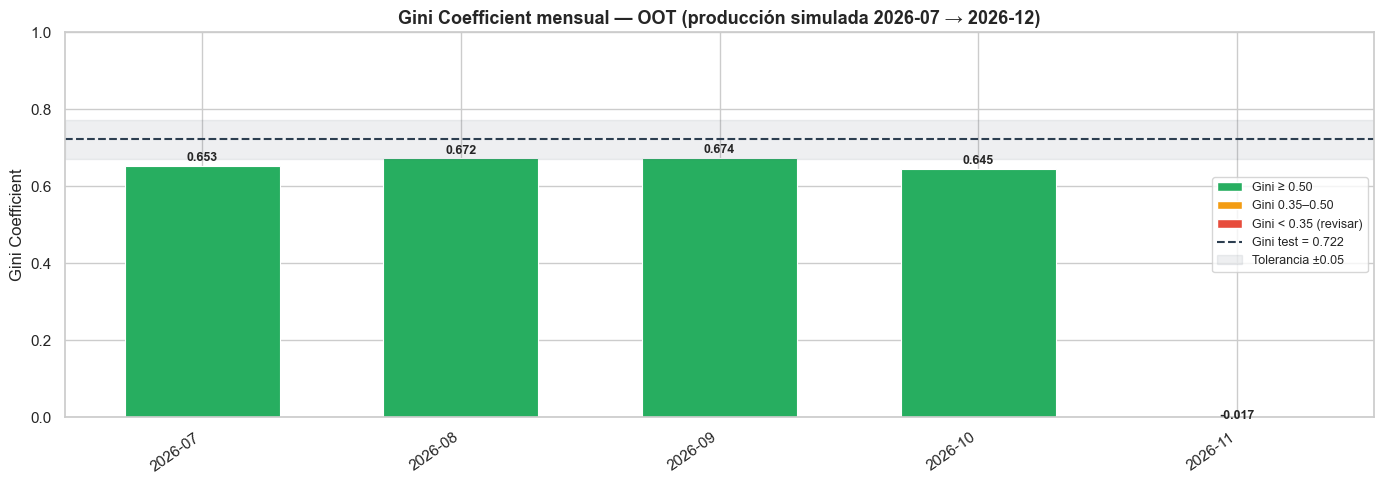

In [22]:
# ──────────────────────────────────────────────────────────────────
# Visualización — Gini mensual en OOT
# ──────────────────────────────────────────────────────────────────
def plot_gini_mensual(monthly_df, gini_ref, save_path=None):
    periodos  = monthly_df['periodo']
    x         = range(len(periodos))
    gini_vals = monthly_df['gini']

    fig, ax = plt.subplots(figsize=(14, 5))
    bar_colors = ['#27ae60' if (not pd.isna(g) and g>=0.5)
                  else '#f39c12' if (not pd.isna(g) and g>=0.35)
                  else '#e74c3c' for g in gini_vals]

    ax.bar(x, gini_vals, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6)
    ax.axhline(gini_ref, color='#2c3e50', linestyle='--', linewidth=1.5,
               label=f'Gini test = {gini_ref:.3f}')
    ax.axhspan(gini_ref-0.05, gini_ref+0.05, alpha=0.08, color='#2c3e50',
               label='Tolerancia ±0.05')

    for xi, val in zip(x, gini_vals):
        if pd.notna(val):
            ax.text(xi, val+0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#27ae60', label='Gini ≥ 0.50'),
        Patch(facecolor='#f39c12', label='Gini 0.35–0.50'),
        Patch(facecolor='#e74c3c', label='Gini < 0.35 (revisar)'),
    ]
    ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-2:], fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(periodos, rotation=35, ha='right')
    ax.set_ylabel('Gini Coefficient', fontsize=12)
    ax.set_title('Gini Coefficient mensual — OOT (producción simulada 2026-07 → 2026-12)',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

gini_test_ref = 2 * metadata['test_auc_roc'] - 1
plot_gini_mensual(monthly_df, gini_ref=gini_test_ref,
                  save_path=f'{FIGURES_PATH}gini_mensual_oot.png')

In [23]:
# ──────────────────────────────────────────────────────────────────
# Resumen del scoring OOT
# ──────────────────────────────────────────────────────────────────
valid_gini = monthly_df['gini'].dropna()
valid_auc  = monthly_df['auc_roc'].dropna()

print('=== RESUMEN OOT — Producción Simulada ===')
print(f'Períodos evaluados  : {len(monthly_df)}')
print(f'Clientes/mes        : {monthly_df["n_clientes"].mean():.0f}')
print(f'AUC promedio OOT    : {valid_auc.mean():.4f}  (min {valid_auc.min():.4f} | max {valid_auc.max():.4f})')
print(f'Gini promedio OOT   : {valid_gini.mean():.4f}  (min {valid_gini.min():.4f} | max {valid_gini.max():.4f})')
print(f'Gini en Test        : {gini_test_ref:.4f}')
print(f'Δ Gini OOT vs Test  : {valid_gini.mean()-gini_test_ref:+.4f}')
print(f'% Churn en Muy alto : {monthly_df["churn_en_muy_alto"].mean():.1f}%')
print()
print(monthly_df[['periodo','n_clientes','n_churn','churn_rate','auc_roc','gini','churn_en_muy_alto']].to_string(index=False))


=== RESUMEN OOT — Producción Simulada ===
Períodos evaluados  : 5
Clientes/mes        : 9103
AUC promedio OOT    : 0.7627  (min 0.4914 | max 0.8369)
Gini promedio OOT   : 0.5255  (min -0.0171 | max 0.6739)
Gini en Test        : 0.7220
Δ Gini OOT vs Test  : -0.1965
% Churn en Muy alto : 18.7%

periodo  n_clientes  n_churn  churn_rate  auc_roc    gini  churn_en_muy_alto
2026-07        9102      834      0.0916   0.8268  0.6535               18.2
2026-08        9104      859      0.0944   0.8361  0.6722               16.3
2026-09        9073      834      0.0919   0.8369  0.6739               21.1
2026-10        9096      787      0.0865   0.8225  0.6450               18.4
2026-11        9140      859      0.0940   0.4914 -0.0171               19.4


In [24]:
monthly_df.to_csv(f'{REGISTRY_PATH}monthly_oot_scoring_v2.0.csv', index=False)
print('✓ Guardado: models/registry/monthly_oot_scoring_v2.0.csv')


✓ Guardado: models/registry/monthly_oot_scoring_v2.0.csv
